In [ ]:
!unzip "/images.zip" -d "/content/data"


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/images/validation/fear/9040.jpg  
  inflating: /content/data/images/validation/fear/9101.jpg  
  inflating: /content/data/images/validation/fear/911.jpg  
  inflating: /content/data/images/validation/fear/9179.jpg  
  inflating: /content/data/images/validation/fear/9205.jpg  
  inflating: /content/data/images/validation/fear/9232.jpg  
  inflating: /content/data/images/validation/fear/9251.jpg  
  inflating: /content/data/images/validation/fear/9261.jpg  
  inflating: /content/data/images/validation/fear/9281.jpg  
  inflating: /content/data/images/validation/fear/9302.jpg  
  inflating: /content/data/images/validation/fear/9333.jpg  
  inflating: /content/data/images/validation/fear/9369.jpg  
  inflating: /content/data/images/validation/fear/9370.jpg  
  inflating: /content/data/images/validation/fear/9474.jpg  
  inflating: /content/data/images/validation/fear/949.jpg  
  inflating: /content/data/images/va

In [ ]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

# PyTorch and related modules
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset

!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall

from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import cv2

# ===================== PATHS & HYPERPARAMETERS =====================
trainData = r"/content/data/images/train"
validationData = r"/content/data/images/validation"

batchSize = 32
epochNumber = 150
learnR = 0.0001
decayR = 1e-4
numClasses = 7

# ===================== MODEL =====================
class EmotionDetector(nn.Module):
    def __init__(self, numClasses=7):
        super(EmotionDetector, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.6)

        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 96, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.7)

        self.fc1 = nn.Linear(96 * 6 * 6, 512)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, numClasses)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.conv3(x))
        x = self.pool2(x)

        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

# ===================== DATASET =====================
class CV2ImageDataset(Dataset):
    def __init__(self, rootDir):
        if not os.path.exists(rootDir):
            raise FileNotFoundError(f"Directory not found: {rootDir}")
        self.imageFolder = datasets.ImageFolder(rootDir)

    def __len__(self):
        return len(self.imageFolder.samples)

    def __getitem__(self, idx):
        imgPath, label = self.imageFolder.samples[idx]
        image = cv2.imread(imgPath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (48, 48))
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        image = torch.from_numpy(image)
        return image, label

# ===================== TRAINING =====================
def trainModel(model, trainLoader, validationLoader, criterion,
               optimizer, epochs, device, metrics, numOfBatches):

    history = {'trainLoss': [], 'valLoss': [], 'valAccuracy': [],
               'valPrecision': [], 'valRecall': []}

    bestValLoss = float('inf')
    accuracy, precision, recall = metrics

    for epoch in range(1, epochs + 1):
        model.train()
        running_train_loss = 0.0

        for inputs, labels in trainLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        epochTrainLoss = running_train_loss / len(trainLoader.dataset)
        history['trainLoss'].append(epochTrainLoss)

        model.eval()
        running_val_loss = 0.0
        preds, targets = [], []

        accuracy.reset()
        precision.reset()
        recall.reset()

        with torch.no_grad():
            for inputs, labels in validationLoader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)
                preds.append(predicted)
                targets.append(labels)

        preds = torch.cat(preds)
        targets = torch.cat(targets)

        epochValLoss = running_val_loss / len(validationLoader.dataset)
        history['valLoss'].append(epochValLoss)

        history['valAccuracy'].append(accuracy(preds, targets).item())
        history['valPrecision'].append(precision(preds, targets).item())
        history['valRecall'].append(recall(preds, targets).item())

        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {epochTrainLoss:.4f} | "
              f"Val Loss: {epochValLoss:.4f}")

        # SAVE BEST MODEL
        if epochValLoss < bestValLoss:
            bestValLoss = epochValLoss
            torch.save(model.state_dict(),
                       "/content/data/best_emotion_model.pth")

    return history

# ===================== MAIN (UNCHANGED STRUCTURE) =====================
if __name__ == '__main__':

    trainDataset = CV2ImageDataset(trainData)
    validationDataset = CV2ImageDataset(validationData)

    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    validationLoader = DataLoader(validationDataset, batch_size=batchSize)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = EmotionDetector(numClasses).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnR, weight_decay=decayR)

    metrics = (
        Accuracy(task="multiclass", num_classes=numClasses).to(device),
        Precision(task="multiclass", num_classes=numClasses, average='macro').to(device),
        Recall(task="multiclass", num_classes=numClasses, average='macro').to(device)
    )

    history = trainModel(
        model, trainLoader, validationLoader,
        criterion, optimizer, epochNumber,
        device, metrics, len(trainLoader)
    )

    print("\nTraining DONE!")

    # ===================== LOAD BEST MODEL =====================
    model.load_state_dict(torch.load("/content/data/best_emotion_model.pth"))
    model.eval()

    # ===================== EVALUATION =====================
    y_test, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for inputs, labels in validationLoader:
            outputs = model(inputs.to(device))
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            y_test.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm / np.sum(cm), annot=True, fmt=".2%", cmap="Blues")
    plt.title("Normalized Confusion Matrix - CNN")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # ROC Curve
    y_test_bin = label_binarize(y_test, classes=list(range(numClasses)))
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label="CNN")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - CNN")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Training History
    plt.figure(figsize=(12, 4))
    plt.plot(history['trainLoss'], label="Train Loss")
    plt.plot(history['valLoss'], label="Val Loss")
    plt.title("Training History")
    plt.legend()
    plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.8 MB/s eta 0:00:00
Using device: cpu


KeyboardInterrupt: 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.3 MB/s eta 0:00:00
Using device: cuda
Epoch 1/200 | Train Loss: 1.8047 | Val Loss: 1.7825 | Val Acc: 0.2910 | Val Prec: 0.2010 | Val Rec: 0.1932
💾 Best model saved as /content/data/best_emotion_model_1.pth
Epoch 2/200 | Train Loss: 1.7336 | Val Loss: 1.6695 | Val Acc: 0.3654 | Val Prec: 0.2896 | Val Rec: 0.2792
💾 Best model saved as /content/data/best_emotion_model_1.pth
Epoch 3/200 | Train Loss: 1.6553 | Val Loss: 1.5987 | Val Acc: 0.3991 | Val Prec: 0.3230 | Val Rec: 0.3097
💾 Best model saved as /content/data/best_emotion_model_1.pth
Epoch 4/200 | Train Loss: 1.6005 | Val Loss: 1.5255 | Val Acc: 0.4215 | Val Prec: 0.3449 | Val Rec: 0.3299
💾 Best model saved as /content/data/best_emotion_model_1.pth
Epoch 5/200 | Train Loss: 1.5510 | Val Loss: 1.4791 | Val Acc: 0.4391 | Val Prec: 0.3567 | Val Rec: 0.3453
💾 Best model saved as /content/data/best_emotion_model_1.pth
Epoch 6/200 | Train Loss: 1.5198 | Val Loss: 1.4727 | Val Ac

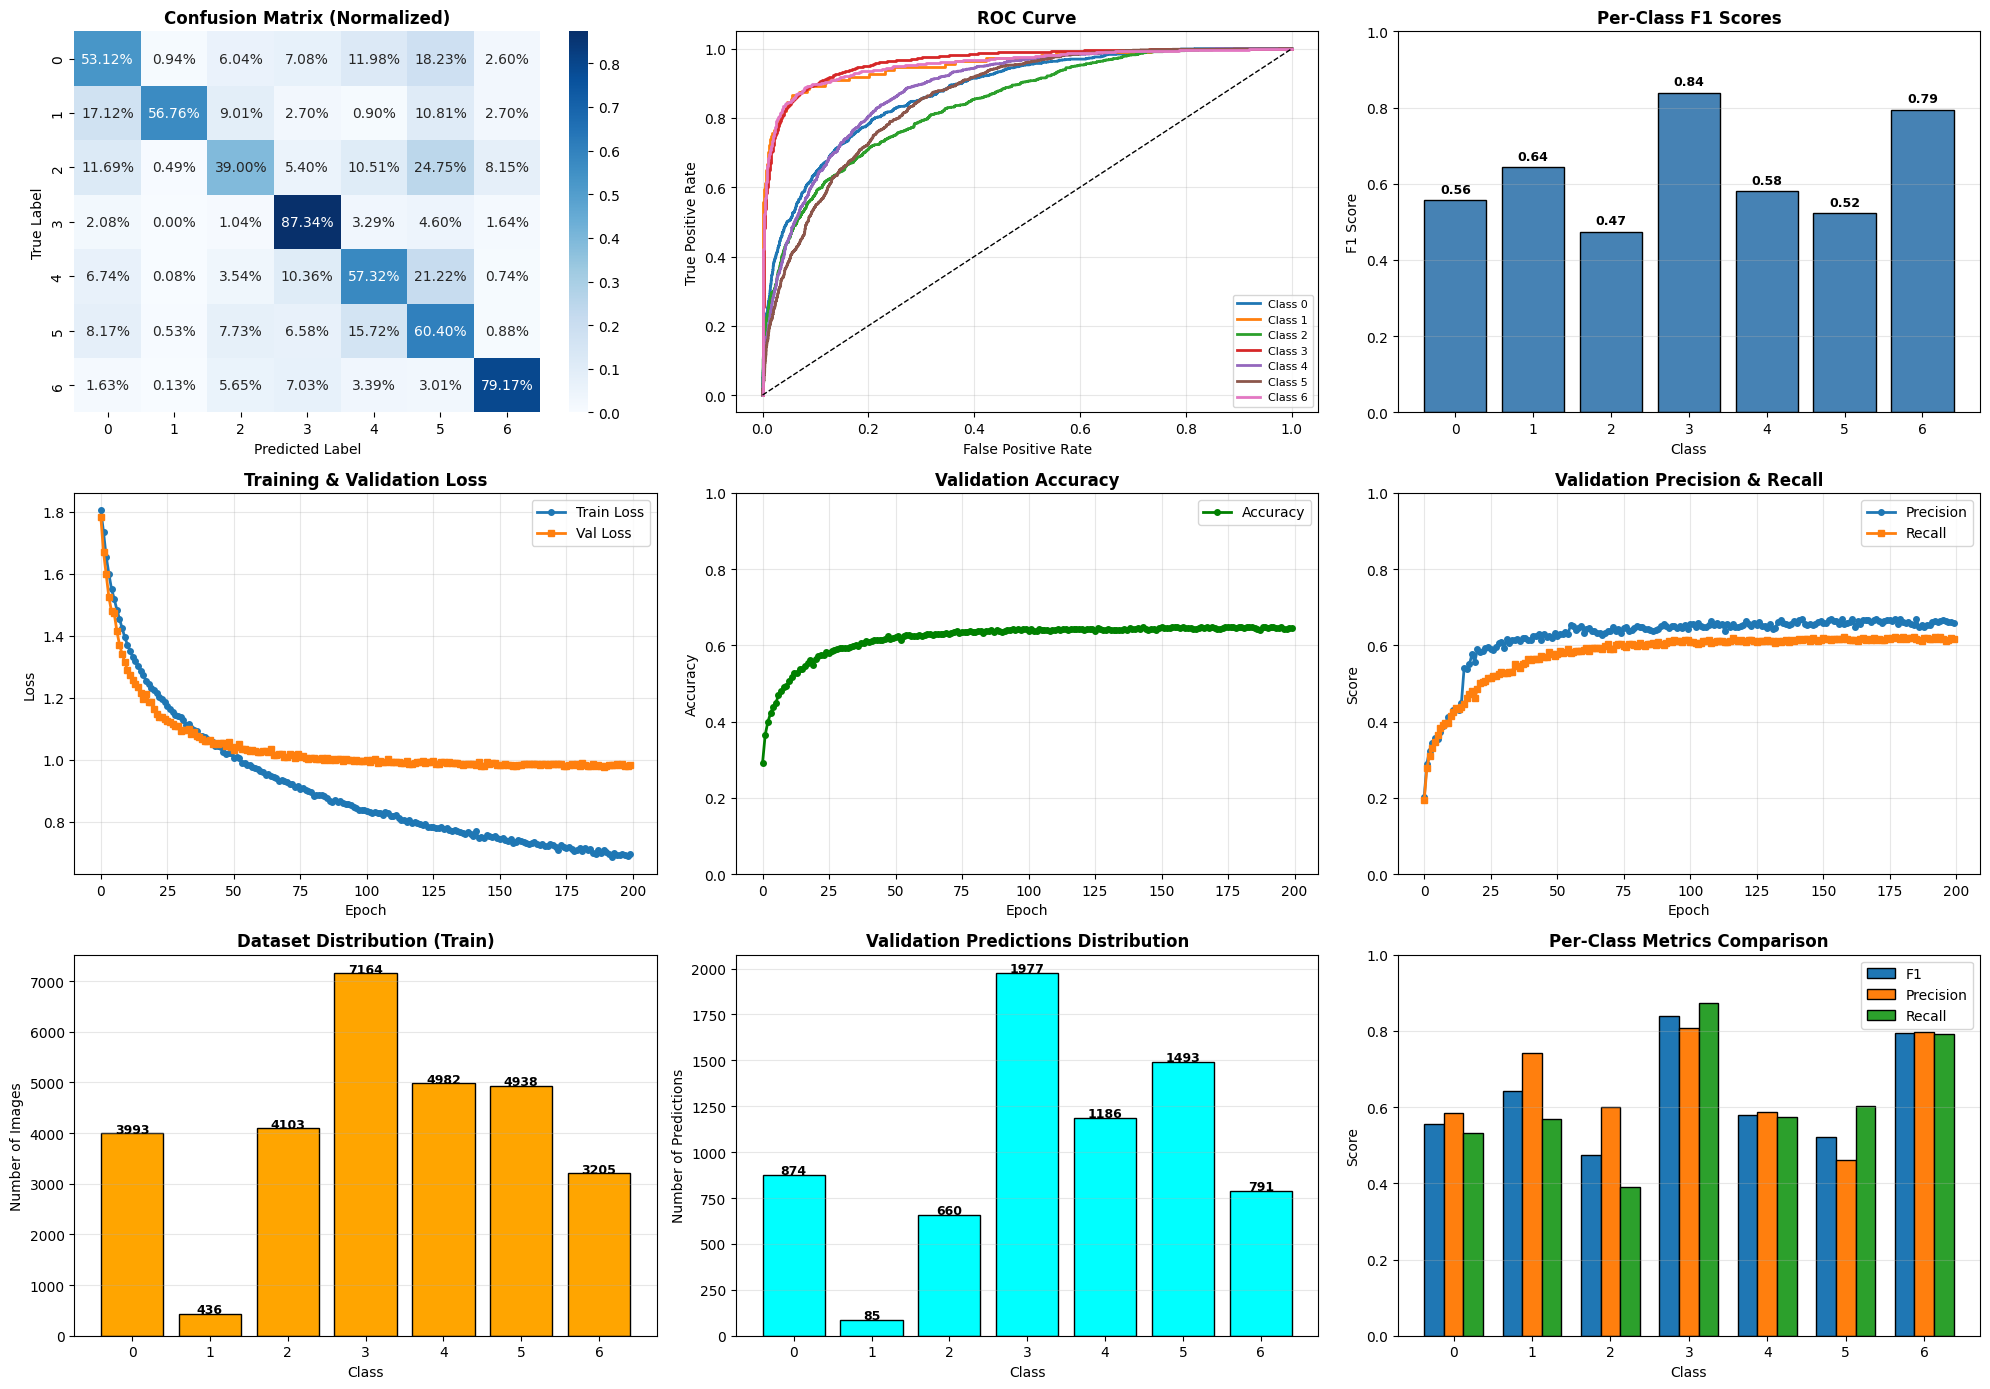


✅ Model successfully trained and saved as /content/data/best_emotion_model_1.pth


In [ ]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import cv2
from collections import Counter

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset

# Metrics
!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# -------------------------- PARAMETERS --------------------------
trainData = r"/content/data/images/train"
validationData = r"/content/data/images/validation"

batchSize = 32
epochNumber = 200
learnR = 0.0001
decayR = 1e-6
numClasses = 7
modelSavePath = "/content/data/best_emotion_model_1.pth"

# -------------------------- MODEL --------------------------
class EmotionDetector(nn.Module):
    def __init__(self, numClasses=7):
        super(EmotionDetector, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.7)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 96, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.7)
        self.fc1 = nn.Linear(96*6*6, 512)
        self.drop3 = nn.Dropout(0.6)
        self.fc2 = nn.Linear(512, numClasses)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

# -------------------------- DATASET --------------------------
class CV2ImageDataset(Dataset):
    def __init__(self, rootDir):
        if not os.path.exists(rootDir):
            raise FileNotFoundError(f"Directory not found: {rootDir}")
        self.imageFolder = datasets.ImageFolder(rootDir)

    def __len__(self):
        return len(self.imageFolder.samples)

    def __getitem__(self, idx):
        imgPath, label = self.imageFolder.samples[idx]
        image = cv2.imread(imgPath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (48, 48))
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        return torch.from_numpy(image), label

# -------------------------- TRAIN FUNCTION --------------------------
def trainModel(model, trainLoader, validationLoader, criterion, optimizer, epochs, device, metrics):
    history = {'trainLoss': [], 'valLoss': [], 'valAccuracy': [], 'valPrecision': [], 'valRecall': []}
    accuracy, precision, recall = metrics
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for inputs, labels in trainLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(trainLoader.dataset)
        history['trainLoss'].append(train_loss)

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss = 0.0
        preds, targets = [], []
        accuracy.reset()
        precision.reset()
        recall.reset()

        with torch.no_grad():
            for inputs, labels in validationLoader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds.append(torch.argmax(outputs, 1))
                targets.append(labels)

        preds = torch.cat(preds)
        targets = torch.cat(targets)
        val_loss /= len(validationLoader.dataset)

        acc = accuracy(preds, targets).item()
        prec = precision(preds, targets).item()
        rec = recall(preds, targets).item()

        history['valLoss'].append(val_loss)
        history['valAccuracy'].append(acc)
        history['valPrecision'].append(prec)
        history['valRecall'].append(rec)

        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {acc:.4f} | "
              f"Val Prec: {prec:.4f} | "
              f"Val Rec: {rec:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), modelSavePath)
            print(f"💾 Best model saved as {modelSavePath}")

    return history

# -------------------------- EVALUATION --------------------------
def evaluateModel(model, validationLoader, device, numClasses, history, trainDataset):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in validationLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, 1)
            preds = torch.argmax(outputs, 1)
            all_preds.append(preds)
            all_labels.append(labels)
            all_probs.append(probs)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)

    # Create a large figure with all subplots
    fig = plt.figure(figsize=(20, 14))

    # -------- 1. Confusion Matrix --------
    cm = ConfusionMatrix(task="multiclass", num_classes=numClasses).to(device)
    cm_matrix = cm(all_preds, all_labels).cpu().numpy()
    cm_norm = cm_matrix.astype(float) / cm_matrix.sum(axis=1)[:, None]

    ax1 = plt.subplot(3, 3, 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=ax1, cbar=True)
    ax1.set_title("Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")

    # -------- 2. ROC Curve --------
    ax2 = plt.subplot(3, 3, 2)
    labels_onehot = label_binarize(all_labels.cpu(), classes=list(range(numClasses)))
    probs_np = all_probs.cpu().numpy()

    for i in range(numClasses):
        fpr, tpr, _ = roc_curve(labels_onehot[:, i], probs_np[:, i])
        ax2.plot(fpr, tpr, label=f"Class {i}", linewidth=2)
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve", fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # -------- 3. Per-class F1 Scores --------
    ax3 = plt.subplot(3, 3, 3)
    f1 = F1Score(task="multiclass", num_classes=numClasses, average=None).to(device)
    f1_scores = f1(all_preds, all_labels).cpu().numpy()

    bars = ax3.bar(range(numClasses), f1_scores, color='steelblue', edgecolor='black')
    ax3.set_title("Per-Class F1 Scores", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Class")
    ax3.set_ylabel("F1 Score")
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(f1_scores):
        ax3.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9, fontweight='bold')

    # -------- 4. Training Loss --------
    ax4 = plt.subplot(3, 3, 4)
    ax4.plot(history['trainLoss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    ax4.plot(history['valLoss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Loss")
    ax4.set_title("Training & Validation Loss", fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # -------- 5. Validation Accuracy --------
    ax5 = plt.subplot(3, 3, 5)
    ax5.plot(history['valAccuracy'], label='Accuracy', linewidth=2, color='green', marker='o', markersize=4)
    ax5.set_xlabel("Epoch")
    ax5.set_ylabel("Accuracy")
    ax5.set_title("Validation Accuracy", fontsize=12, fontweight='bold')
    ax5.set_ylim(0, 1)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # -------- 6. Precision & Recall --------
    ax6 = plt.subplot(3, 3, 6)
    ax6.plot(history['valPrecision'], label='Precision', linewidth=2, marker='o', markersize=4)
    ax6.plot(history['valRecall'], label='Recall', linewidth=2, marker='s', markersize=4)
    ax6.set_xlabel("Epoch")
    ax6.set_ylabel("Score")
    ax6.set_title("Validation Precision & Recall", fontsize=12, fontweight='bold')
    ax6.set_ylim(0, 1)
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # -------- 7. Class Distribution --------
    ax7 = plt.subplot(3, 3, 7)
    counts = Counter([label for _, label in trainDataset])
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    bars = ax7.bar(classes, values, color='orange', edgecolor='black')
    ax7.set_xlabel("Class")
    ax7.set_ylabel("Number of Images")
    ax7.set_title("Dataset Distribution (Train)", fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        ax7.text(classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

    # -------- 8. Prediction Distribution --------
    ax8 = plt.subplot(3, 3, 8)
    pred_counts = Counter(all_preds.cpu().numpy())
    pred_classes = sorted(pred_counts.keys())
    pred_values = [pred_counts[c] for c in pred_classes]
    bars = ax8.bar(pred_classes, pred_values, color='cyan', edgecolor='black')
    ax8.set_xlabel("Class")
    ax8.set_ylabel("Number of Predictions")
    ax8.set_title("Validation Predictions Distribution", fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(pred_values):
        ax8.text(pred_classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

    # -------- 9. Per-class Metrics Summary --------
    ax9 = plt.subplot(3, 3, 9)
    precision_metric = Precision(task="multiclass", num_classes=numClasses, average=None).to(device)
    recall_metric = Recall(task="multiclass", num_classes=numClasses, average=None).to(device)

    prec_scores = precision_metric(all_preds, all_labels).cpu().numpy()
    rec_scores = recall_metric(all_preds, all_labels).cpu().numpy()

    x = np.arange(numClasses)
    width = 0.25

    ax9.bar(x - width, f1_scores, width, label='F1', edgecolor='black')
    ax9.bar(x, prec_scores, width, label='Precision', edgecolor='black')
    ax9.bar(x + width, rec_scores, width, label='Recall', edgecolor='black')
    ax9.set_xlabel("Class")
    ax9.set_ylabel("Score")
    ax9.set_title("Per-Class Metrics Comparison", fontsize=12, fontweight='bold')
    ax9.set_xticks(x)
    ax9.set_ylim(0, 1)
    ax9.legend()
    ax9.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("/content/data/emotion_model_evaluation.png", dpi=300, bbox_inches='tight')
    print("📊 All visualizations saved as emotion_model_evaluation.png")
    plt.show()

# -------------------------- MAIN --------------------------
if __name__ == '__main__':

    trainDataset = CV2ImageDataset(trainData)
    validationDataset = CV2ImageDataset(validationData)

    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    validationLoader = DataLoader(validationDataset, batch_size=batchSize)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = EmotionDetector(numClasses).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnR, weight_decay=decayR)

    metrics = (
        Accuracy(task="multiclass", num_classes=numClasses).to(device),
        Precision(task="multiclass", num_classes=numClasses, average='macro').to(device),
        Recall(task="multiclass", num_classes=numClasses, average='macro').to(device)
    )

    history = trainModel(model, trainLoader, validationLoader,
                         criterion, optimizer, epochNumber, device, metrics)

    model.load_state_dict(torch.load(modelSavePath, map_location=device))
    evaluateModel(model, validationLoader, device, numClasses, history, trainDataset)

    print(f"\n✅ Model successfully trained and saved as {modelSavePath}")


Using device: cuda
Epoch 1/220 | Train Loss: 1.9478 | Val Loss: 1.9519 | Val Acc: 0.0157 | Val Prec: 0.0022 | Val Rec: 0.1429
💾 Best model saved!
Epoch 2/220 | Train Loss: 1.9445 | Val Loss: 1.9485 | Val Acc: 0.0671 | Val Prec: 0.1389 | Val Rec: 0.1825
💾 Best model saved!
Epoch 3/220 | Train Loss: 1.9450 | Val Loss: 1.9479 | Val Acc: 0.0393 | Val Prec: 0.0972 | Val Rec: 0.1649
💾 Best model saved!
Epoch 4/220 | Train Loss: 1.9414 | Val Loss: 1.9450 | Val Acc: 0.1336 | Val Prec: 0.1027 | Val Rec: 0.2072
💾 Best model saved!
Epoch 5/220 | Train Loss: 1.9361 | Val Loss: 1.9326 | Val Acc: 0.2093 | Val Prec: 0.1792 | Val Rec: 0.2025
💾 Best model saved!
Epoch 6/220 | Train Loss: 1.9257 | Val Loss: 1.9241 | Val Acc: 0.1918 | Val Prec: 0.2001 | Val Rec: 0.2046
💾 Best model saved!
Epoch 7/220 | Train Loss: 1.9134 | Val Loss: 1.9009 | Val Acc: 0.2151 | Val Prec: 0.2003 | Val Rec: 0.2125
💾 Best model saved!
Epoch 8/220 | Train Loss: 1.9061 | Val Loss: 1.8990 | Val Acc: 0.2143 | Val Prec: 0.2109 | V

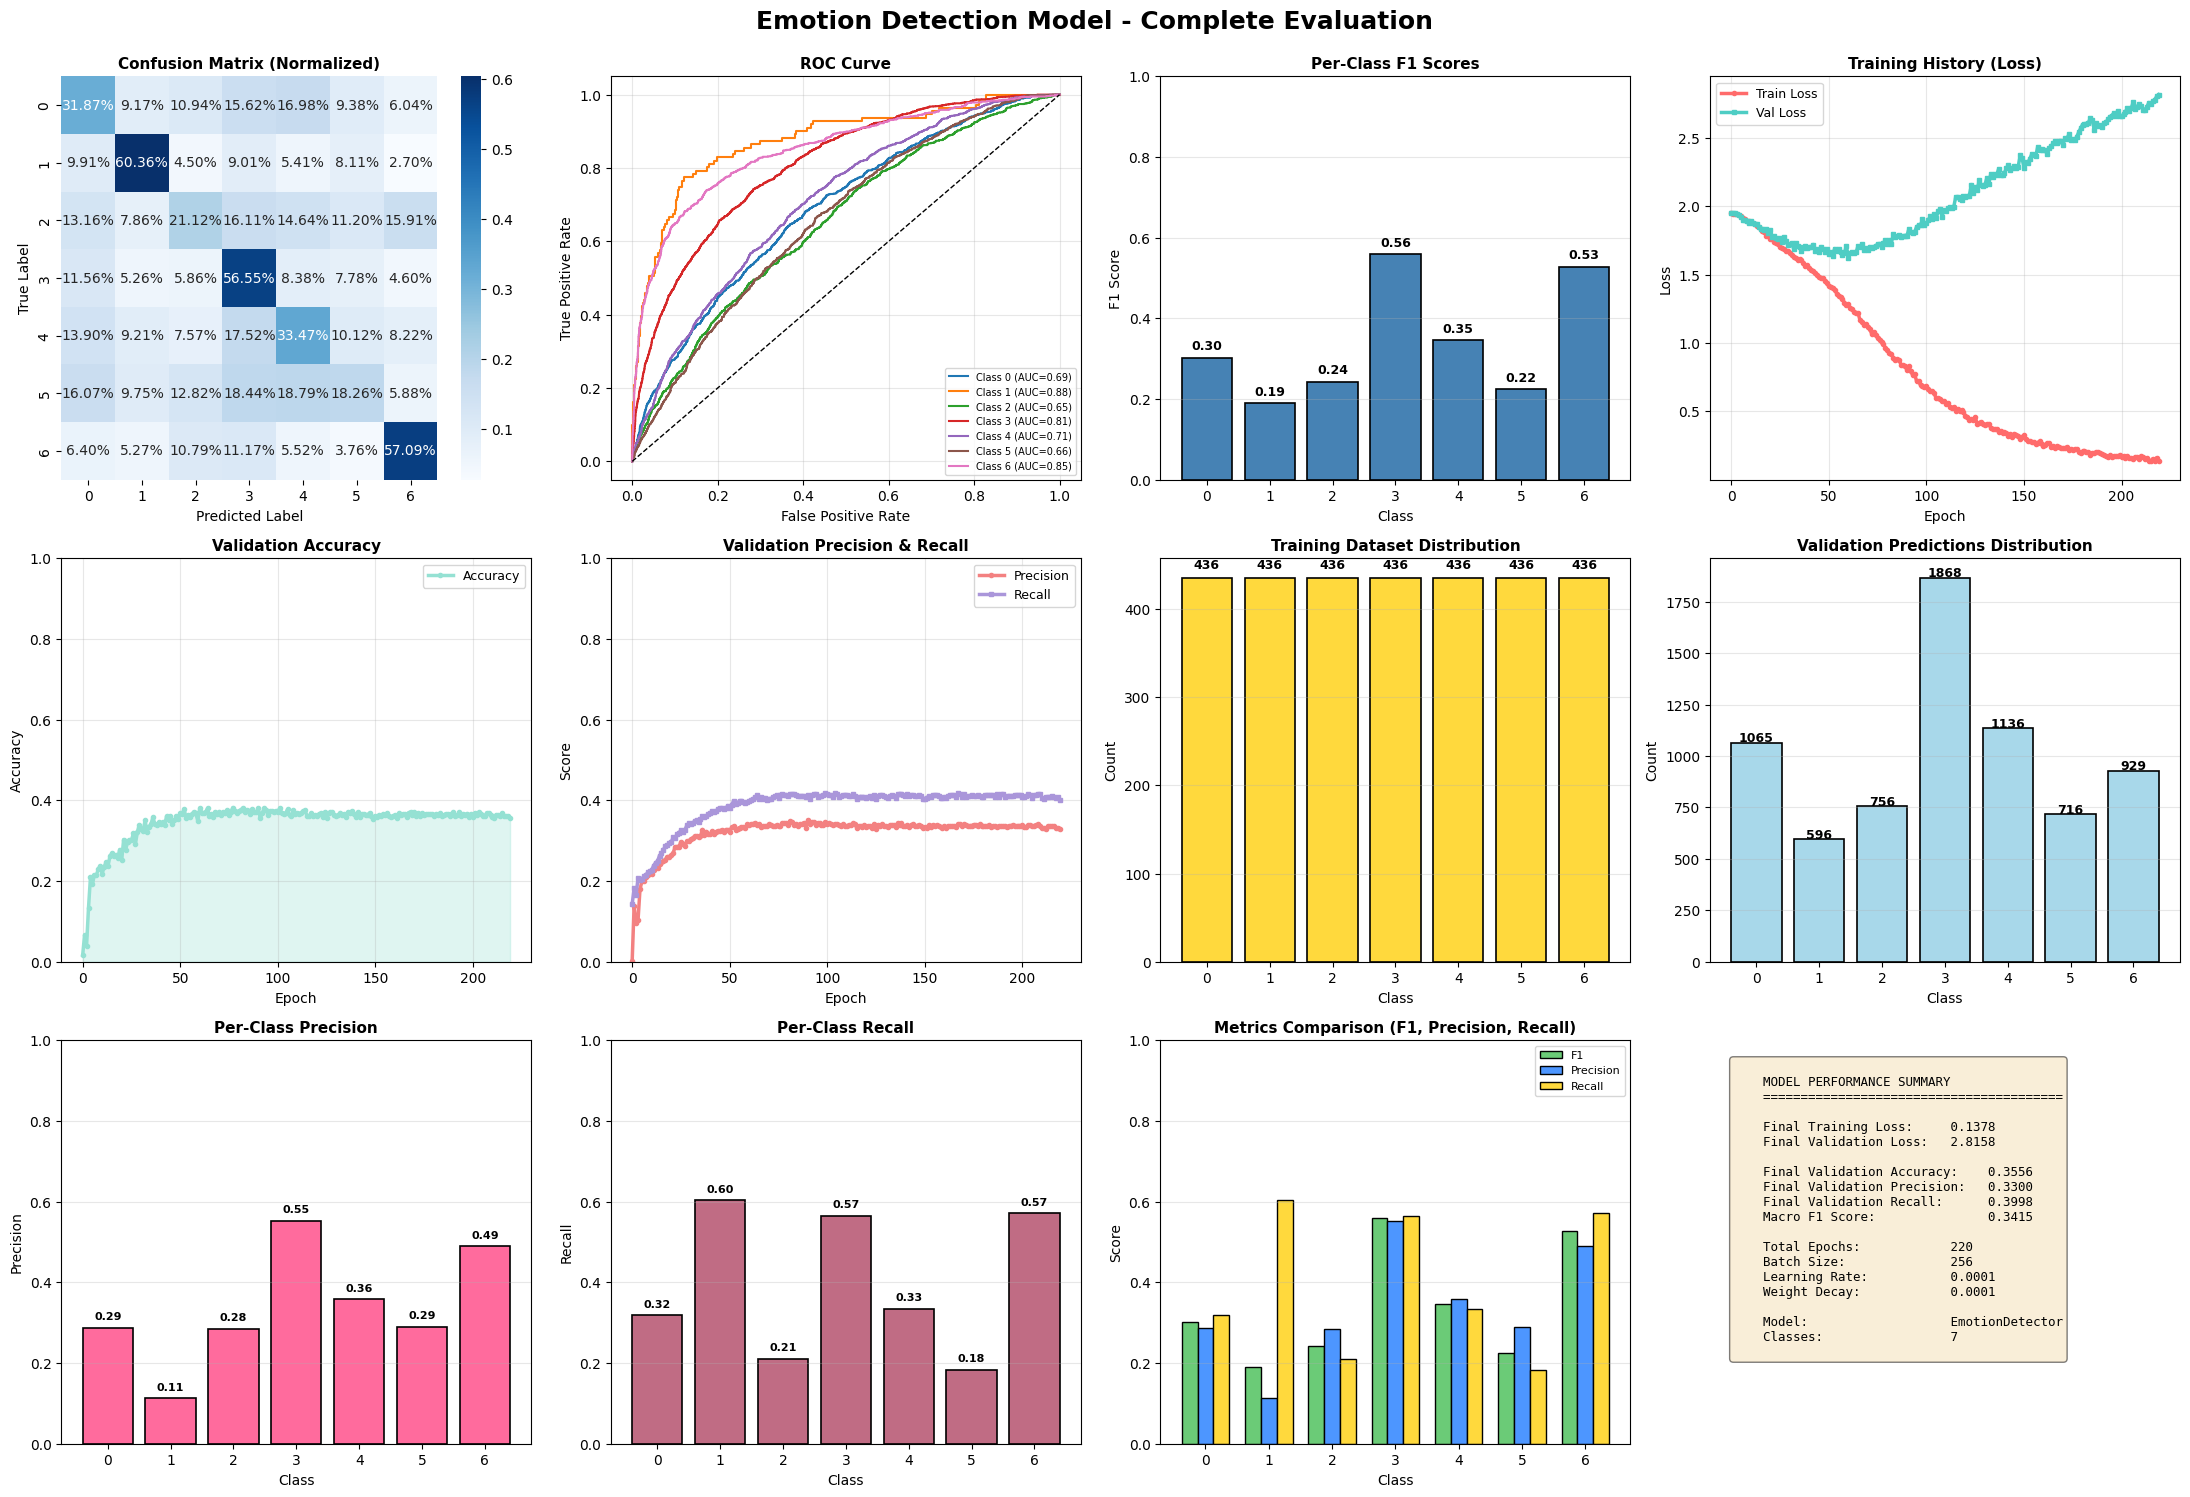


✅ Training Complete!
📁 Model saved: /content/data/best_emotion_model.pth
📊 Visualization saved: /content/data/emotion_model_evaluation.png


In [ ]:
#undersampling


import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math
import cv2
from collections import Counter

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset

# Metrics
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# -------------------------- PARAMETERS --------------------------
trainData = r"/content/data/images/train"
validationData = r"/content/data/images/validation"

batchSize = 256
epochNumber = 220
learnR = 0.0001
decayR = 1e-4
numClasses = 7
modelSavePath = "/content/data/best_emotion_model.pth"
visualizationPath = "/content/data/emotion_model_evaluation.png"

# -------------------------- MODEL --------------------------
class EmotionDetector(nn.Module):
    def __init__(self, numClasses=7):
        super(EmotionDetector, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.5)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 96, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.6)
        self.fc1 = nn.Linear(96*6*6, 512)
        self.drop3 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, numClasses)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

# -------------------------- DATASET --------------------------
class CV2ImageDataset(Dataset):
    def __init__(self, rootDir):
        if not os.path.exists(rootDir):
            raise FileNotFoundError(f"Directory not found: {rootDir}")
        self.imageFolder = datasets.ImageFolder(rootDir)

    def __len__(self):
        return len(self.imageFolder.samples)

    def __getitem__(self, idx):
        imgPath, label = self.imageFolder.samples[idx]
        image = cv2.imread(imgPath)
        if image is None:
            raise IOError(f"No image found: {imgPath}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (48, 48))
        image = image.astype(np.float32)/255.0
        image = np.expand_dims(image, axis=0)
        image = torch.from_numpy(image)
        return image, label

# -------------------------- TRAIN FUNCTION --------------------------
def trainModel(model, trainLoader, validationLoader, criterion, optimizer, epochs, device, metrics, numOfBatches):
    history = {'trainLoss': [], 'valLoss': [], 'valAccuracy': [], 'valPrecision': [], 'valRecall': []}
    accuracy, precision, recall = metrics
    best_val_loss = float('inf')

    for epoch in range(1, epochs+1):
        epochStart = time.time()
        model.train()
        running_train_loss = 0.0
        for batchIdx, (inputs, labels) in enumerate(trainLoader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
        epochTrainLoss = running_train_loss / len(trainLoader.dataset)
        history['trainLoss'].append(epochTrainLoss)

        # -------------------- VALIDATION --------------------
        model.eval()
        running_val_loss = 0.0
        valPreds, valTargets = [], []
        accuracy.reset(); precision.reset(); recall.reset()
        with torch.no_grad():
            for inputs, labels in validationLoader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valPreds.append(preds)
                valTargets.append(labels)
        valPreds = torch.cat(valPreds)
        valTargets = torch.cat(valTargets)
        epochValLoss = running_val_loss / len(validationLoader.dataset)
        epochValAcc = accuracy(valPreds, valTargets).item()
        epochValPrec = precision(valPreds, valTargets).item()
        epochValRec = recall(valPreds, valTargets).item()
        history['valLoss'].append(epochValLoss)
        history['valAccuracy'].append(epochValAcc)
        history['valPrecision'].append(epochValPrec)
        history['valRecall'].append(epochValRec)

        # -------------------- PRINT --------------------
        print(f"Epoch {epoch}/{epochs} | Train Loss: {epochTrainLoss:.4f} | Val Loss: {epochValLoss:.4f} | "
              f"Val Acc: {epochValAcc:.4f} | Val Prec: {epochValPrec:.4f} | Val Rec: {epochValRec:.4f}")

        # -------------------- SAVE BEST MODEL --------------------
        if epochValLoss < best_val_loss:
            best_val_loss = epochValLoss
            torch.save(model.state_dict(), modelSavePath)
            print("💾 Best model saved!")

    return history

# -------------------------- EVALUATION --------------------------
def evaluateModel(model, validationLoader, device, numClasses, history, trainDataset):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in validationLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, 1)
            preds = torch.argmax(outputs, 1)
            all_preds.append(preds)
            all_labels.append(labels)
            all_probs.append(probs)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)

    # Create a large figure with all subplots (3x4 grid)
    fig = plt.figure(figsize=(22, 15))
    fig.suptitle("Emotion Detection Model - Complete Evaluation", fontsize=18, fontweight='bold', y=0.995)

    # -------- 1. Confusion Matrix --------
    cm_metric = ConfusionMatrix(task="multiclass", num_classes=numClasses).to(device)
    cm = cm_metric(all_preds, all_labels).cpu().numpy()
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    ax1 = plt.subplot(3, 4, 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=ax1, cbar=True)
    ax1.set_title("Confusion Matrix (Normalized)", fontsize=11, fontweight='bold')
    ax1.set_ylabel("True Label")
    ax1.set_xlabel("Predicted Label")

    # -------- 2. ROC Curve --------
    ax2 = plt.subplot(3, 4, 2)
    labels_onehot = label_binarize(all_labels.cpu(), classes=list(range(numClasses)))
    probs_np = all_probs.cpu().numpy()

    for i in range(numClasses):
        fpr, tpr, _ = roc_curve(labels_onehot[:,i], probs_np[:,i])
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})", linewidth=1.5)
    ax2.plot([0,1],[0,1],'k--', linewidth=1)
    ax2.set_xlabel("False Positive Rate", fontsize=10)
    ax2.set_ylabel("True Positive Rate", fontsize=10)
    ax2.set_title("ROC Curve", fontsize=11, fontweight='bold')
    ax2.legend(fontsize=7, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # -------- 3. Per-Class F1 Scores --------
    f1_per_class = F1Score(task="multiclass", num_classes=numClasses, average=None).to(device)
    per_class_f1 = f1_per_class(all_preds, all_labels).cpu().numpy()

    ax3 = plt.subplot(3, 4, 3)
    bars = ax3.bar(range(numClasses), per_class_f1, color='steelblue', edgecolor='black', linewidth=1.2)
    ax3.set_title("Per-Class F1 Scores", fontsize=11, fontweight='bold')
    ax3.set_xlabel("Class")
    ax3.set_ylabel("F1 Score")
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(per_class_f1):
        ax3.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9, fontweight='bold')

    # -------- 4. Training & Validation Loss --------
    ax4 = plt.subplot(3, 4, 4)
    ax4.plot(history['trainLoss'], label="Train Loss", linewidth=2.5, marker='o', markersize=3, color='#FF6B6B')
    ax4.plot(history['valLoss'], label="Val Loss", linewidth=2.5, marker='s', markersize=3, color='#4ECDC4')
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Loss")
    ax4.set_title("Training History (Loss)", fontsize=11, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    # -------- 5. Validation Accuracy --------
    ax5 = plt.subplot(3, 4, 5)
    ax5.plot(history['valAccuracy'], label='Accuracy', linewidth=2.5, color='#95E1D3', marker='o', markersize=3)
    ax5.fill_between(range(len(history['valAccuracy'])), history['valAccuracy'], alpha=0.3, color='#95E1D3')
    ax5.set_xlabel("Epoch")
    ax5.set_ylabel("Accuracy")
    ax5.set_title("Validation Accuracy", fontsize=11, fontweight='bold')
    ax5.set_ylim(0, 1)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)

    # -------- 6. Precision & Recall --------
    ax6 = plt.subplot(3, 4, 6)
    ax6.plot(history['valPrecision'], label='Precision', linewidth=2.5, marker='o', markersize=3, color='#F38181')
    ax6.plot(history['valRecall'], label='Recall', linewidth=2.5, marker='s', markersize=3, color='#AA96DA')
    ax6.set_xlabel("Epoch")
    ax6.set_ylabel("Score")
    ax6.set_title("Validation Precision & Recall", fontsize=11, fontweight='bold')
    ax6.set_ylim(0, 1)
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)

    # -------- 7. Training Dataset Distribution --------
    ax7 = plt.subplot(3, 4, 7)
    counts = Counter([label for _, label in trainDataset])
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    bars = ax7.bar(classes, values, color='#FFD93D', edgecolor='black', linewidth=1.2)
    ax7.set_xlabel("Class")
    ax7.set_ylabel("Count")
    ax7.set_title("Training Dataset Distribution", fontsize=11, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        ax7.text(classes[i], v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

    # -------- 8. Validation Predictions Distribution --------
    ax8 = plt.subplot(3, 4, 8)
    pred_counts = Counter(all_preds.cpu().numpy())
    pred_classes = sorted(pred_counts.keys())
    pred_values = [pred_counts[c] for c in pred_classes]
    bars = ax8.bar(pred_classes, pred_values, color='#A8D8EA', edgecolor='black', linewidth=1.2)
    ax8.set_xlabel("Class")
    ax8.set_ylabel("Count")
    ax8.set_title("Validation Predictions Distribution", fontsize=11, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(pred_values):
        ax8.text(pred_classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

    # -------- 9. Per-class Metrics (Precision) --------
    precision_metric = Precision(task="multiclass", num_classes=numClasses, average=None).to(device)
    prec_scores = precision_metric(all_preds, all_labels).cpu().numpy()

    ax9 = plt.subplot(3, 4, 9)
    bars = ax9.bar(range(numClasses), prec_scores, color='#FF6B9D', edgecolor='black', linewidth=1.2)
    ax9.set_xlabel("Class")
    ax9.set_ylabel("Precision")
    ax9.set_title("Per-Class Precision", fontsize=11, fontweight='bold')
    ax9.set_ylim(0, 1)
    ax9.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(prec_scores):
        ax9.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8, fontweight='bold')

    # -------- 10. Per-class Metrics (Recall) --------
    recall_metric = Recall(task="multiclass", num_classes=numClasses, average=None).to(device)
    rec_scores = recall_metric(all_preds, all_labels).cpu().numpy()

    ax10 = plt.subplot(3, 4, 10)
    bars = ax10.bar(range(numClasses), rec_scores, color='#C06C84', edgecolor='black', linewidth=1.2)
    ax10.set_xlabel("Class")
    ax10.set_ylabel("Recall")
    ax10.set_title("Per-Class Recall", fontsize=11, fontweight='bold')
    ax10.set_ylim(0, 1)
    ax10.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(rec_scores):
        ax10.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8, fontweight='bold')

    # -------- 11. Combined Metrics Comparison --------
    ax11 = plt.subplot(3, 4, 11)
    x = np.arange(numClasses)
    width = 0.25

    bars1 = ax11.bar(x - width, per_class_f1, width, label='F1', color='#6BCB77', edgecolor='black', linewidth=1)
    bars2 = ax11.bar(x, prec_scores, width, label='Precision', color='#4D96FF', edgecolor='black', linewidth=1)
    bars3 = ax11.bar(x + width, rec_scores, width, label='Recall', color='#FFD93D', edgecolor='black', linewidth=1)

    ax11.set_xlabel("Class")
    ax11.set_ylabel("Score")
    ax11.set_title("Metrics Comparison (F1, Precision, Recall)", fontsize=11, fontweight='bold')
    ax11.set_xticks(x)
    ax11.set_ylim(0, 1)
    ax11.legend(fontsize=8)
    ax11.grid(True, alpha=0.3, axis='y')

    # -------- 12. Model Summary Stats --------
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')

    f1_macro = F1Score(task="multiclass", num_classes=numClasses, average="macro").to(device)
    macro_f1 = f1_macro(all_preds, all_labels).item()

    final_train_loss = history['trainLoss'][-1]
    final_val_loss = history['valLoss'][-1]
    final_accuracy = history['valAccuracy'][-1]
    final_precision = history['valPrecision'][-1]
    final_recall = history['valRecall'][-1]

    summary_text = f"""
    MODEL PERFORMANCE SUMMARY
    {'='*40}

    Final Training Loss:     {final_train_loss:.4f}
    Final Validation Loss:   {final_val_loss:.4f}

    Final Validation Accuracy:    {final_accuracy:.4f}
    Final Validation Precision:   {final_precision:.4f}
    Final Validation Recall:      {final_recall:.4f}
    Macro F1 Score:               {macro_f1:.4f}

    Total Epochs:            {len(history['trainLoss'])}
    Batch Size:              {batchSize}
    Learning Rate:           {learnR}
    Weight Decay:            {decayR}

    Model:                   EmotionDetector
    Classes:                 {numClasses}
    """

    ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, fontsize=9,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(visualizationPath, dpi=300, bbox_inches='tight')
    print(f"📊 All visualizations saved as {visualizationPath}")
    plt.show()

# -------------------------- MAIN --------------------------
if __name__ == '__main__':
    # ---- DATASETS ----
    trainDataset = CV2ImageDataset(trainData)
    validationDataset = CV2ImageDataset(validationData)

    # -------------------- BALANCE DATASET (UNDERSAMPLING) --------------------
    class_counts = Counter([label for _, label in trainDataset])
    min_count = min(class_counts.values())
    balanced_samples = []
    samples_by_class = {i: [] for i in range(numClasses)}
    for img, label in trainDataset.imageFolder.samples:
        samples_by_class[label].append((img, label))
    for cls in range(numClasses):
        balanced_samples.extend(samples_by_class[cls][:min_count])
    trainDataset.imageFolder.samples = balanced_samples
    trainDataset.imageFolder.targets = [label for _, label in balanced_samples]

    # -------------------- DATALOADERS --------------------
    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True, num_workers=0)
    validationLoader = DataLoader(validationDataset, batch_size=batchSize, shuffle=False, num_workers=0)

    # -------------------- DEVICE --------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # -------------------- MODEL --------------------
    model = EmotionDetector(numClasses=numClasses).to(device)

    # -------------------- CRITERION & OPTIMIZER --------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnR, weight_decay=decayR)

    # -------------------- METRICS --------------------
    valAccuracyMetric = Accuracy(task="multiclass", num_classes=numClasses).to(device)
    valPrecisionMetric = Precision(task="multiclass", num_classes=numClasses, average='macro').to(device)
    valRecallMetric = Recall(task="multiclass", num_classes=numClasses, average='macro').to(device)
    metrics = (valAccuracyMetric, valPrecisionMetric, valRecallMetric)

    # -------------------- TRAIN --------------------
    history = trainModel(model, trainLoader, validationLoader, criterion, optimizer, epochNumber, device, metrics, numOfBatches=math.ceil(len(trainDataset)/batchSize))

    # -------------------- LOAD BEST MODEL --------------------
    model.load_state_dict(torch.load(modelSavePath, map_location=device))
    print("✅ Best model loaded for evaluation!")

    # -------------------- EVALUATION --------------------
    evaluateModel(model, validationLoader, device, numClasses, history, trainDataset)

    print(f"\n✅ Training Complete!")
    print(f"📁 Model saved: {modelSavePath}")
    print(f"📊 Visualization saved: {visualizationPath}")

Using device: cuda
Epoch 1/200 | Train Loss: 1.0771 | Val Loss: 1.0637 | Val Acc: 0.4476 | Val Prec: 0.3639 | Val Rec: 0.3849
💾 Best model saved as /content/data/model_2.pth
Epoch 2/200 | Train Loss: 1.0314 | Val Loss: 0.9760 | Val Acc: 0.5526 | Val Prec: 0.5290 | Val Rec: 0.5235
💾 Best model saved as /content/data/model_2.pth
Epoch 3/200 | Train Loss: 0.9655 | Val Loss: 0.9151 | Val Acc: 0.5864 | Val Prec: 0.5725 | Val Rec: 0.5580
💾 Best model saved as /content/data/model_2.pth
Epoch 4/200 | Train Loss: 0.9219 | Val Loss: 0.8758 | Val Acc: 0.6100 | Val Prec: 0.5854 | Val Rec: 0.5796
💾 Best model saved as /content/data/model_2.pth
Epoch 5/200 | Train Loss: 0.8854 | Val Loss: 0.8373 | Val Acc: 0.6242 | Val Prec: 0.5977 | Val Rec: 0.5882
💾 Best model saved as /content/data/model_2.pth
Epoch 6/200 | Train Loss: 0.8587 | Val Loss: 0.8054 | Val Acc: 0.6447 | Val Prec: 0.6190 | Val Rec: 0.6184
💾 Best model saved as /content/data/model_2.pth
Epoch 7/200 | Train Loss: 0.8364 | Val Loss: 0.7789

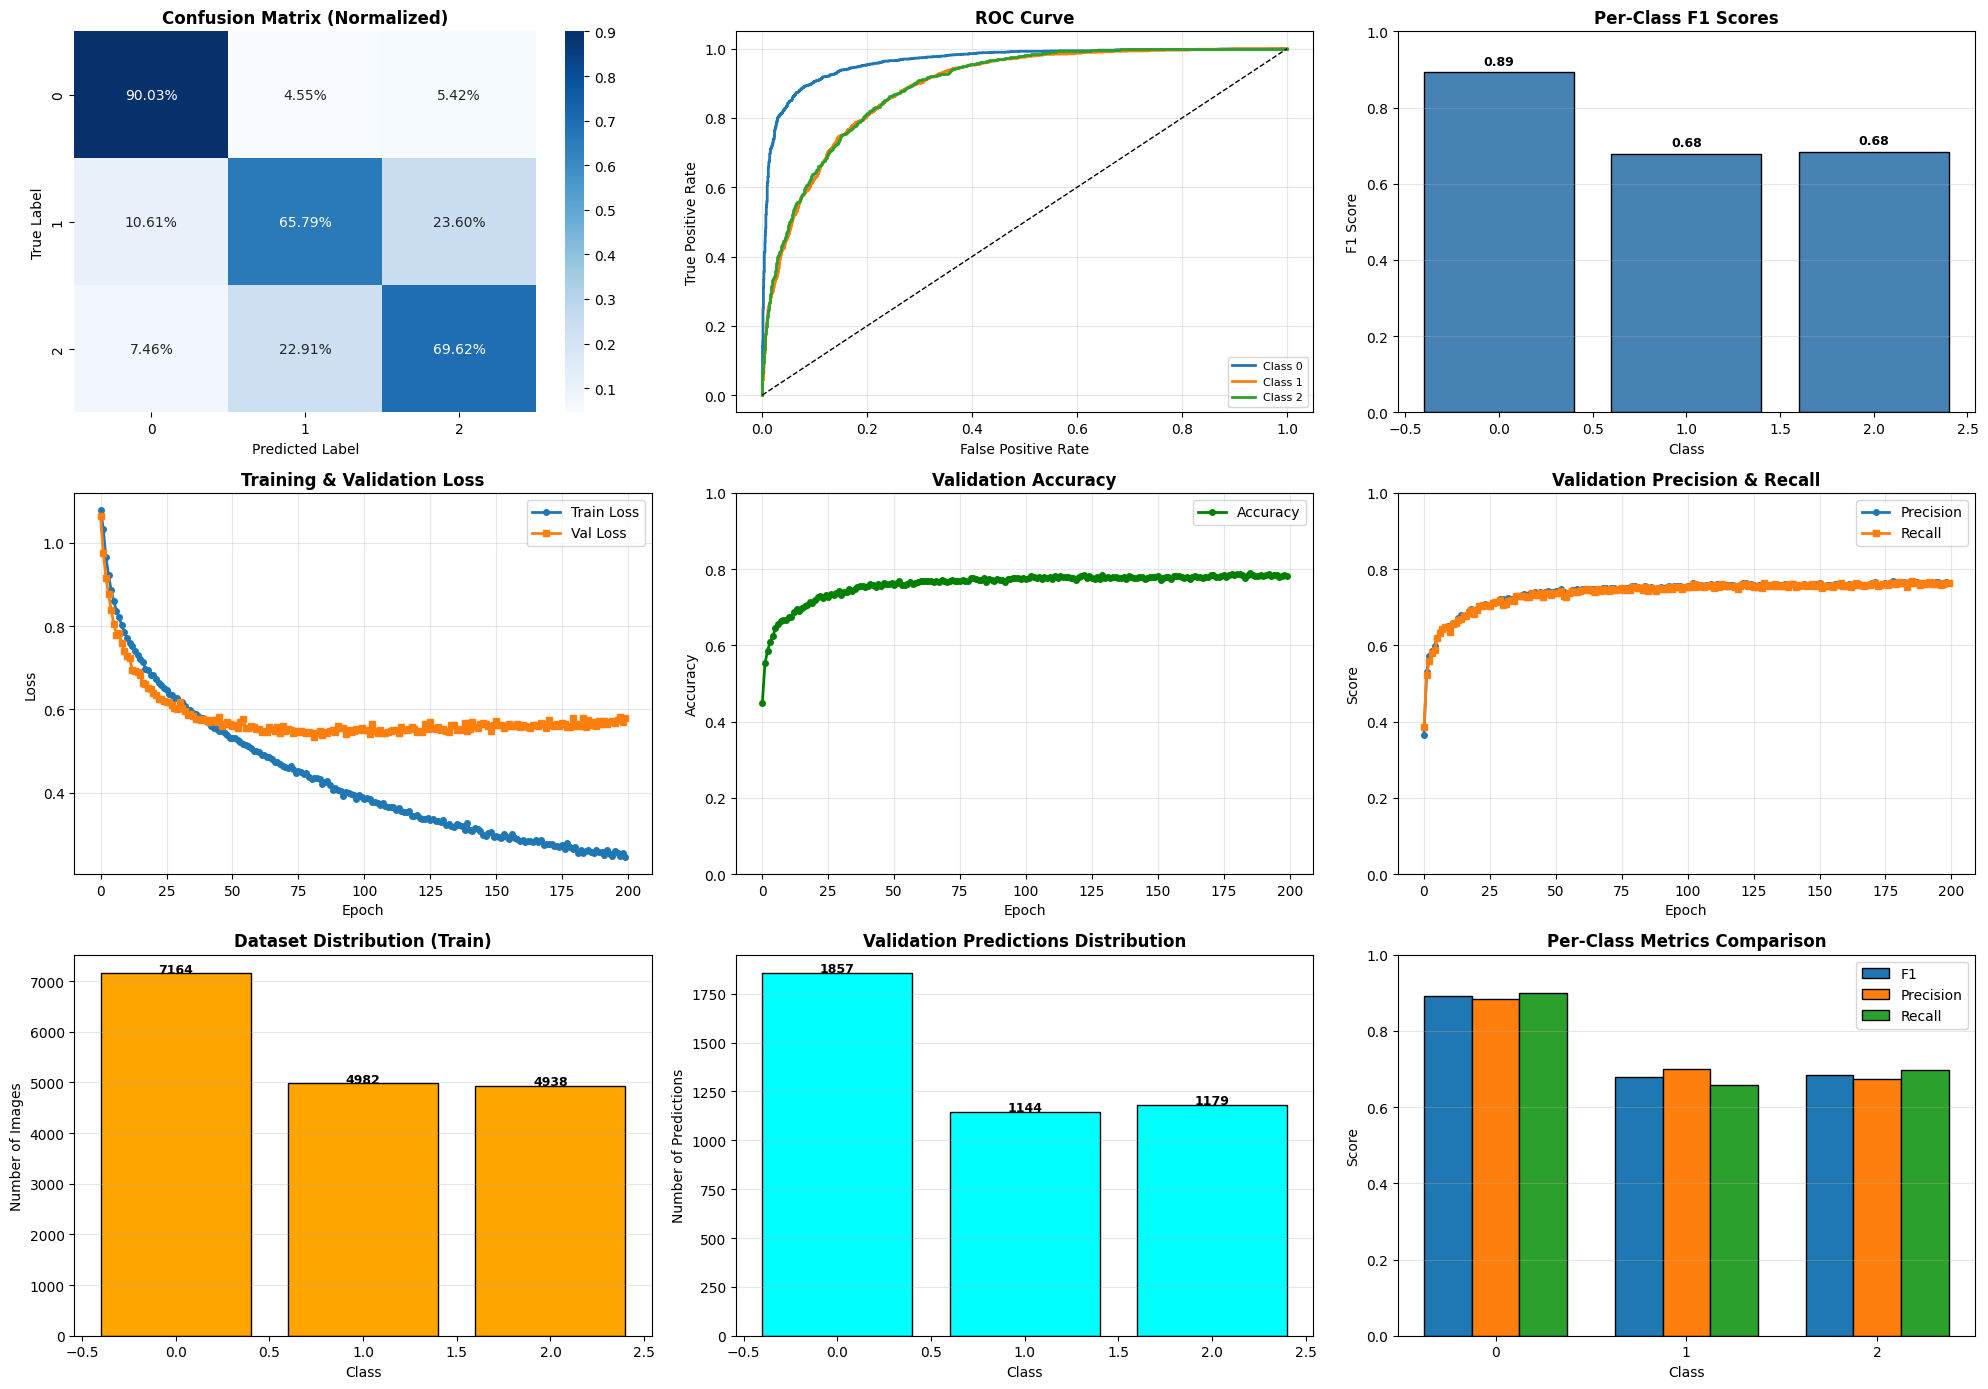


✅ Model successfully trained and saved as /content/data/model_2.pth


In [ ]:
#only 3 emotions


import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import cv2
from collections import Counter
# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
# Metrics
!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
# -------------------------- PARAMETERS --------------------------
trainData = r"/content/data/images/train"
validationData = r"/content/data/images/validation"
batchSize = 32
epochNumber = 200
learnR = 0.0001
decayR = 1e-6
numClasses = 3
modelSavePath = "/content/data/model_2.pth"
# -------------------------- MODEL --------------------------
class EmotionDetector(nn.Module):
    def __init__(self, numClasses=7):
        super(EmotionDetector, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.7)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 96, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.7)
        self.fc1 = nn.Linear(96*6*6, 512)
        self.drop3 = nn.Dropout(0.6)
        self.fc2 = nn.Linear(512, numClasses)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x
# -------------------------- DATASET --------------------------
class CV2ImageDataset(Dataset):
    def __init__(self, rootDir):
        if not os.path.exists(rootDir):
            raise FileNotFoundError(f"Directory not found: {rootDir}")
        self.imageFolder = datasets.ImageFolder(rootDir)
        # Filter to only desired original labels: happy=3, natural=4, sad=5
        desired_original_labels = [3, 4, 5]
        label_map = {3: 0, 4: 1, 5: 2}
        self.samples = [(path, label_map[label]) for path, label in self.imageFolder.samples if label in desired_original_labels]
        if len(self.samples) == 0:
            raise ValueError("No samples found for the desired classes.")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        imgPath, label = self.samples[idx]
        image = cv2.imread(imgPath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (48, 48))
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        return torch.from_numpy(image), label
# -------------------------- TRAIN FUNCTION --------------------------
def trainModel(model, trainLoader, validationLoader, criterion, optimizer, epochs, device, metrics):
    history = {'trainLoss': [], 'valLoss': [], 'valAccuracy': [], 'valPrecision': [], 'valRecall': []}
    accuracy, precision, recall = metrics
    best_val_loss = float('inf')
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for inputs, labels in trainLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(trainLoader.dataset)
        history['trainLoss'].append(train_loss)
        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss = 0.0
        preds, targets = [], []
        accuracy.reset()
        precision.reset()
        recall.reset()
        with torch.no_grad():
            for inputs, labels in validationLoader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds.append(torch.argmax(outputs, 1))
                targets.append(labels)
        preds = torch.cat(preds)
        targets = torch.cat(targets)
        val_loss /= len(validationLoader.dataset)
        acc = accuracy(preds, targets).item()
        prec = precision(preds, targets).item()
        rec = recall(preds, targets).item()
        history['valLoss'].append(val_loss)
        history['valAccuracy'].append(acc)
        history['valPrecision'].append(prec)
        history['valRecall'].append(rec)
        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {acc:.4f} | "
              f"Val Prec: {prec:.4f} | "
              f"Val Rec: {rec:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), modelSavePath)
            print(f"💾 Best model saved as {modelSavePath}")
    return history
# -------------------------- EVALUATION --------------------------
def evaluateModel(model, validationLoader, device, numClasses, history, trainDataset):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in validationLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, 1)
            preds = torch.argmax(outputs, 1)
            all_preds.append(preds)
            all_labels.append(labels)
            all_probs.append(probs)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)
    # Create a large figure with all subplots
    fig = plt.figure(figsize=(20, 14))
    # -------- 1. Confusion Matrix --------
    cm = ConfusionMatrix(task="multiclass", num_classes=numClasses).to(device)
    cm_matrix = cm(all_preds, all_labels).cpu().numpy()
    cm_norm = cm_matrix.astype(float) / cm_matrix.sum(axis=1)[:, None]
    ax1 = plt.subplot(3, 3, 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=ax1, cbar=True)
    ax1.set_title("Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")
    # -------- 2. ROC Curve --------
    ax2 = plt.subplot(3, 3, 2)
    labels_onehot = label_binarize(all_labels.cpu(), classes=list(range(numClasses)))
    probs_np = all_probs.cpu().numpy()
    for i in range(numClasses):
        fpr, tpr, _ = roc_curve(labels_onehot[:, i], probs_np[:, i])
        ax2.plot(fpr, tpr, label=f"Class {i}", linewidth=2)
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve", fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(True, alpha=0.3)
    # -------- 3. Per-class F1 Scores --------
    ax3 = plt.subplot(3, 3, 3)
    f1 = F1Score(task="multiclass", num_classes=numClasses, average=None).to(device)
    f1_scores = f1(all_preds, all_labels).cpu().numpy()
    bars = ax3.bar(range(numClasses), f1_scores, color='steelblue', edgecolor='black')
    ax3.set_title("Per-Class F1 Scores", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Class")
    ax3.set_ylabel("F1 Score")
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(f1_scores):
        ax3.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9, fontweight='bold')
    # -------- 4. Training Loss --------
    ax4 = plt.subplot(3, 3, 4)
    ax4.plot(history['trainLoss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    ax4.plot(history['valLoss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Loss")
    ax4.set_title("Training & Validation Loss", fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    # -------- 5. Validation Accuracy --------
    ax5 = plt.subplot(3, 3, 5)
    ax5.plot(history['valAccuracy'], label='Accuracy', linewidth=2, color='green', marker='o', markersize=4)
    ax5.set_xlabel("Epoch")
    ax5.set_ylabel("Accuracy")
    ax5.set_title("Validation Accuracy", fontsize=12, fontweight='bold')
    ax5.set_ylim(0, 1)
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    # -------- 6. Precision & Recall --------
    ax6 = plt.subplot(3, 3, 6)
    ax6.plot(history['valPrecision'], label='Precision', linewidth=2, marker='o', markersize=4)
    ax6.plot(history['valRecall'], label='Recall', linewidth=2, marker='s', markersize=4)
    ax6.set_xlabel("Epoch")
    ax6.set_ylabel("Score")
    ax6.set_title("Validation Precision & Recall", fontsize=12, fontweight='bold')
    ax6.set_ylim(0, 1)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    # -------- 7. Class Distribution --------
    ax7 = plt.subplot(3, 3, 7)
    counts = Counter([label for _, label in trainDataset])
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    bars = ax7.bar(classes, values, color='orange', edgecolor='black')
    ax7.set_xlabel("Class")
    ax7.set_ylabel("Number of Images")
    ax7.set_title("Dataset Distribution (Train)", fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        ax7.text(classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
    # -------- 8. Prediction Distribution --------
    ax8 = plt.subplot(3, 3, 8)
    pred_counts = Counter(all_preds.cpu().numpy())
    pred_classes = sorted(pred_counts.keys())
    pred_values = [pred_counts[c] for c in pred_classes]
    bars = ax8.bar(pred_classes, pred_values, color='cyan', edgecolor='black')
    ax8.set_xlabel("Class")
    ax8.set_ylabel("Number of Predictions")
    ax8.set_title("Validation Predictions Distribution", fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(pred_values):
        ax8.text(pred_classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
    # -------- 9. Per-class Metrics Summary --------
    ax9 = plt.subplot(3, 3, 9)
    precision_metric = Precision(task="multiclass", num_classes=numClasses, average=None).to(device)
    recall_metric = Recall(task="multiclass", num_classes=numClasses, average=None).to(device)
    prec_scores = precision_metric(all_preds, all_labels).cpu().numpy()
    rec_scores = recall_metric(all_preds, all_labels).cpu().numpy()
    x = np.arange(numClasses)
    width = 0.25
    ax9.bar(x - width, f1_scores, width, label='F1', edgecolor='black')
    ax9.bar(x, prec_scores, width, label='Precision', edgecolor='black')
    ax9.bar(x + width, rec_scores, width, label='Recall', edgecolor='black')
    ax9.set_xlabel("Class")
    ax9.set_ylabel("Score")
    ax9.set_title("Per-Class Metrics Comparison", fontsize=12, fontweight='bold')
    ax9.set_xticks(x)
    ax9.set_ylim(0, 1)
    ax9.legend()
    ax9.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig("/content/data/emotion_model_evaluation.png", dpi=300, bbox_inches='tight')
    print("📊 All visualizations saved as emotion_model_evaluation.png")
    plt.show()
# -------------------------- MAIN --------------------------
if __name__ == '__main__':
    trainDataset = CV2ImageDataset(trainData)
    validationDataset = CV2ImageDataset(validationData)
    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    validationLoader = DataLoader(validationDataset, batch_size=batchSize)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = EmotionDetector(numClasses).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnR, weight_decay=decayR)
    metrics = (
        Accuracy(task="multiclass", num_classes=numClasses).to(device),
        Precision(task="multiclass", num_classes=numClasses, average='macro').to(device),
        Recall(task="multiclass", num_classes=numClasses, average='macro').to(device)
    )
    history = trainModel(model, trainLoader, validationLoader,
                         criterion, optimizer, epochNumber, device, metrics)
    model.load_state_dict(torch.load(modelSavePath, map_location=device))
    evaluateModel(model, validationLoader, device, numClasses, history, trainDataset)
    print(f"\n✅ Model successfully trained and saved as {modelSavePath}")

Using device: cuda
Epoch 1/200 | Train Loss: 1.3233 | Val Loss: 1.2827 | Val Acc: 0.4025 | Val Prec: 0.4598 | Val Rec: 0.3540
💾 Best model saved as /content/data/model_3.pth
Epoch 2/200 | Train Loss: 1.2371 | Val Loss: 1.1412 | Val Acc: 0.5053 | Val Prec: 0.5257 | Val Rec: 0.4671
💾 Best model saved as /content/data/model_3.pth
Epoch 3/200 | Train Loss: 1.1475 | Val Loss: 1.1078 | Val Acc: 0.5268 | Val Prec: 0.5602 | Val Rec: 0.4781
💾 Best model saved as /content/data/model_3.pth
Epoch 4/200 | Train Loss: 1.0916 | Val Loss: 1.0176 | Val Acc: 0.5809 | Val Prec: 0.5853 | Val Rec: 0.5475
💾 Best model saved as /content/data/model_3.pth
Epoch 5/200 | Train Loss: 1.0531 | Val Loss: 0.9816 | Val Acc: 0.5931 | Val Prec: 0.6025 | Val Rec: 0.5641
💾 Best model saved as /content/data/model_3.pth
Epoch 6/200 | Train Loss: 1.0143 | Val Loss: 0.9443 | Val Acc: 0.6086 | Val Prec: 0.5995 | Val Rec: 0.5775
💾 Best model saved as /content/data/model_3.pth
Epoch 7/200 | Train Loss: 0.9888 | Val Loss: 0.9185

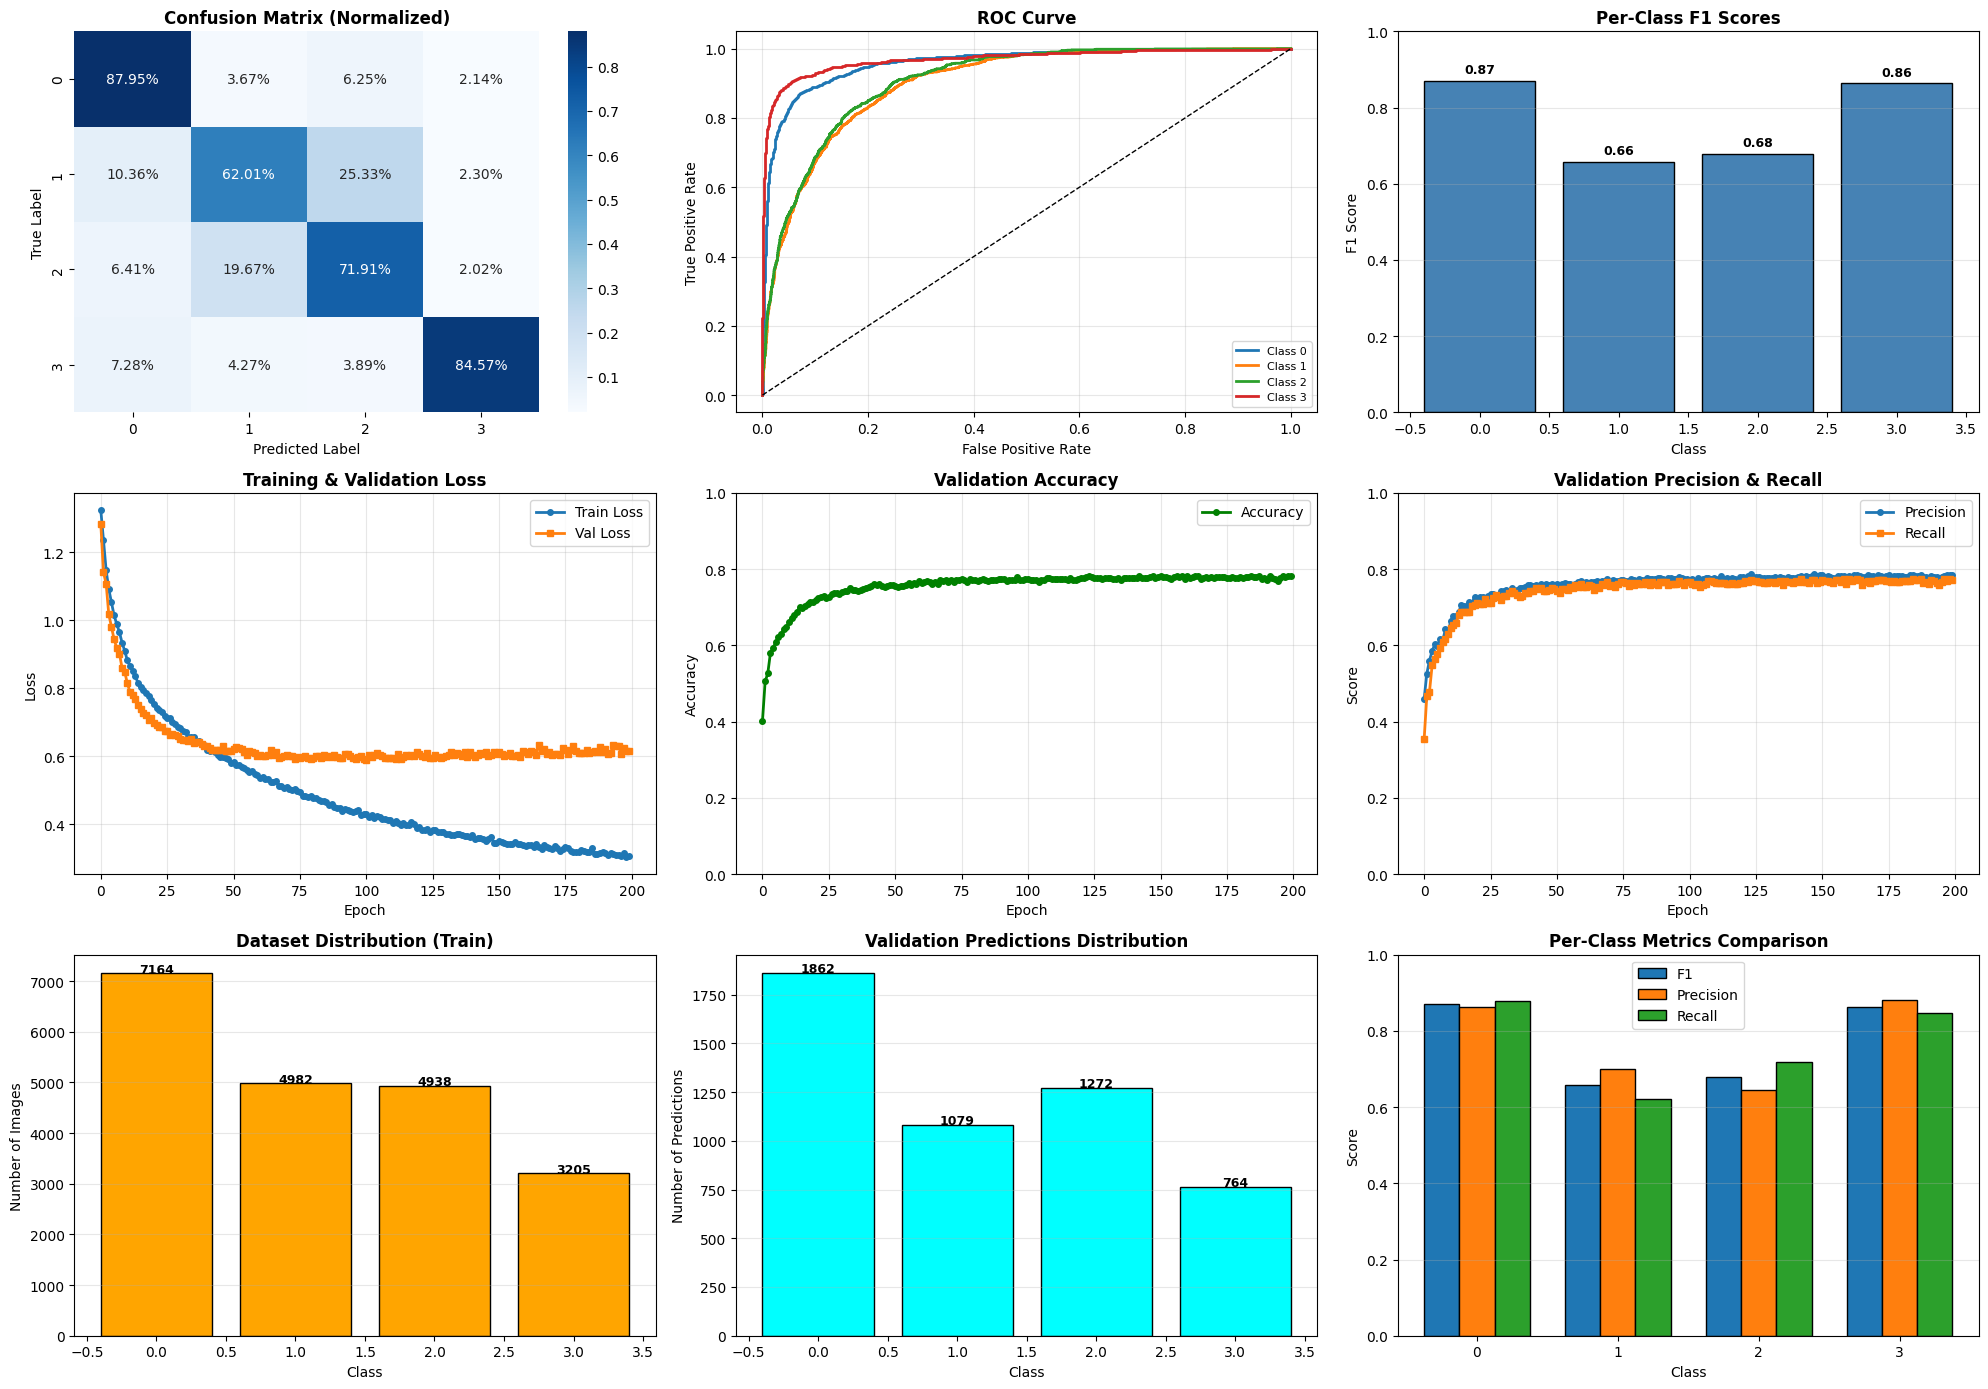


✅ Model successfully trained and saved as /content/data/model_3.pth


In [ ]:
# this 4 emotions predict happy,natural,sad,suprise

import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import cv2
from collections import Counter
# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
# Metrics
!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
# -------------------------- PARAMETERS --------------------------
trainData = r"/content/data/images/train"
validationData = r"/content/data/images/validation"
batchSize = 32
epochNumber = 200
learnR = 0.0001
decayR = 1e-6
numClasses = 4
modelSavePath = "/content/data/model_3.pth"
# -------------------------- MODEL --------------------------
class EmotionDetector(nn.Module):
    def __init__(self, numClasses=4):
        super(EmotionDetector, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.7)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 96, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.7)
        self.fc1 = nn.Linear(96*6*6, 512)
        self.drop3 = nn.Dropout(0.6)
        self.fc2 = nn.Linear(512, numClasses)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x
# -------------------------- DATASET --------------------------
class CV2ImageDataset(Dataset):
    def __init__(self, rootDir):
        if not os.path.exists(rootDir):
            raise FileNotFoundError(f"Directory not found: {rootDir}")
        self.imageFolder = datasets.ImageFolder(rootDir)
        # Filter to only desired original labels: happy=3, neutral=4, sad=5, surprise=6
        desired_original_labels = [3, 4, 5, 6]
        label_map = {3: 0, 4: 1, 5: 2, 6: 3}
        self.samples = [(path, label_map[label]) for path, label in self.imageFolder.samples if label in desired_original_labels]
        if len(self.samples) == 0:
            raise ValueError("No samples found for the desired classes.")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        imgPath, label = self.samples[idx]
        image = cv2.imread(imgPath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (48, 48))
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        return torch.from_numpy(image), label
# -------------------------- TRAIN FUNCTION --------------------------
def trainModel(model, trainLoader, validationLoader, criterion, optimizer, epochs, device, metrics):
    history = {'trainLoss': [], 'valLoss': [], 'valAccuracy': [], 'valPrecision': [], 'valRecall': []}
    accuracy, precision, recall = metrics
    best_val_loss = float('inf')
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for inputs, labels in trainLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(trainLoader.dataset)
        history['trainLoss'].append(train_loss)
        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss = 0.0
        preds, targets = [], []
        accuracy.reset()
        precision.reset()
        recall.reset()
        with torch.no_grad():
            for inputs, labels in validationLoader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds.append(torch.argmax(outputs, 1))
                targets.append(labels)
        preds = torch.cat(preds)
        targets = torch.cat(targets)
        val_loss /= len(validationLoader.dataset)
        acc = accuracy(preds, targets).item()
        prec = precision(preds, targets).item()
        rec = recall(preds, targets).item()
        history['valLoss'].append(val_loss)
        history['valAccuracy'].append(acc)
        history['valPrecision'].append(prec)
        history['valRecall'].append(rec)
        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {acc:.4f} | "
              f"Val Prec: {prec:.4f} | "
              f"Val Rec: {rec:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), modelSavePath)
            print(f"💾 Best model saved as {modelSavePath}")
    return history
# -------------------------- EVALUATION --------------------------
def evaluateModel(model, validationLoader, device, numClasses, history, trainDataset):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in validationLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, 1)
            preds = torch.argmax(outputs, 1)
            all_preds.append(preds)
            all_labels.append(labels)
            all_probs.append(probs)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)
    # Create a large figure with all subplots
    fig = plt.figure(figsize=(20, 14))
    # -------- 1. Confusion Matrix --------
    cm = ConfusionMatrix(task="multiclass", num_classes=numClasses).to(device)
    cm_matrix = cm(all_preds, all_labels).cpu().numpy()
    cm_norm = cm_matrix.astype(float) / cm_matrix.sum(axis=1)[:, None]
    ax1 = plt.subplot(3, 3, 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=ax1, cbar=True)
    ax1.set_title("Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")
    # -------- 2. ROC Curve --------
    ax2 = plt.subplot(3, 3, 2)
    labels_onehot = label_binarize(all_labels.cpu(), classes=list(range(numClasses)))
    probs_np = all_probs.cpu().numpy()
    for i in range(numClasses):
        fpr, tpr, _ = roc_curve(labels_onehot[:, i], probs_np[:, i])
        ax2.plot(fpr, tpr, label=f"Class {i}", linewidth=2)
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve", fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(True, alpha=0.3)
    # -------- 3. Per-class F1 Scores --------
    ax3 = plt.subplot(3, 3, 3)
    f1 = F1Score(task="multiclass", num_classes=numClasses, average=None).to(device)
    f1_scores = f1(all_preds, all_labels).cpu().numpy()
    bars = ax3.bar(range(numClasses), f1_scores, color='steelblue', edgecolor='black')
    ax3.set_title("Per-Class F1 Scores", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Class")
    ax3.set_ylabel("F1 Score")
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(f1_scores):
        ax3.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9, fontweight='bold')
    # -------- 4. Training Loss --------
    ax4 = plt.subplot(3, 3, 4)
    ax4.plot(history['trainLoss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    ax4.plot(history['valLoss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Loss")
    ax4.set_title("Training & Validation Loss", fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    # -------- 5. Validation Accuracy --------
    ax5 = plt.subplot(3, 3, 5)
    ax5.plot(history['valAccuracy'], label='Accuracy', linewidth=2, color='green', marker='o', markersize=4)
    ax5.set_xlabel("Epoch")
    ax5.set_ylabel("Accuracy")
    ax5.set_title("Validation Accuracy", fontsize=12, fontweight='bold')
    ax5.set_ylim(0, 1)
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    # -------- 6. Precision & Recall --------
    ax6 = plt.subplot(3, 3, 6)
    ax6.plot(history['valPrecision'], label='Precision', linewidth=2, marker='o', markersize=4)
    ax6.plot(history['valRecall'], label='Recall', linewidth=2, marker='s', markersize=4)
    ax6.set_xlabel("Epoch")
    ax6.set_ylabel("Score")
    ax6.set_title("Validation Precision & Recall", fontsize=12, fontweight='bold')
    ax6.set_ylim(0, 1)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    # -------- 7. Class Distribution --------
    ax7 = plt.subplot(3, 3, 7)
    counts = Counter([label for _, label in trainDataset])
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    bars = ax7.bar(classes, values, color='orange', edgecolor='black')
    ax7.set_xlabel("Class")
    ax7.set_ylabel("Number of Images")
    ax7.set_title("Dataset Distribution (Train)", fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        ax7.text(classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
    # -------- 8. Prediction Distribution --------
    ax8 = plt.subplot(3, 3, 8)
    pred_counts = Counter(all_preds.cpu().numpy())
    pred_classes = sorted(pred_counts.keys())
    pred_values = [pred_counts[c] for c in pred_classes]
    bars = ax8.bar(pred_classes, pred_values, color='cyan', edgecolor='black')
    ax8.set_xlabel("Class")
    ax8.set_ylabel("Number of Predictions")
    ax8.set_title("Validation Predictions Distribution", fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(pred_values):
        ax8.text(pred_classes[i], v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
    # -------- 9. Per-class Metrics Summary --------
    ax9 = plt.subplot(3, 3, 9)
    precision_metric = Precision(task="multiclass", num_classes=numClasses, average=None).to(device)
    recall_metric = Recall(task="multiclass", num_classes=numClasses, average=None).to(device)
    prec_scores = precision_metric(all_preds, all_labels).cpu().numpy()
    rec_scores = recall_metric(all_preds, all_labels).cpu().numpy()
    x = np.arange(numClasses)
    width = 0.25
    ax9.bar(x - width, f1_scores, width, label='F1', edgecolor='black')
    ax9.bar(x, prec_scores, width, label='Precision', edgecolor='black')
    ax9.bar(x + width, rec_scores, width, label='Recall', edgecolor='black')
    ax9.set_xlabel("Class")
    ax9.set_ylabel("Score")
    ax9.set_title("Per-Class Metrics Comparison", fontsize=12, fontweight='bold')
    ax9.set_xticks(x)
    ax9.set_ylim(0, 1)
    ax9.legend()
    ax9.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig("/content/data/emotion_model_evaluation.png", dpi=300, bbox_inches='tight')
    print("📊 All visualizations saved as emotion_model_evaluation.png")
    plt.show()
# -------------------------- MAIN --------------------------
if __name__ == '__main__':
    trainDataset = CV2ImageDataset(trainData)
    validationDataset = CV2ImageDataset(validationData)
    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    validationLoader = DataLoader(validationDataset, batch_size=batchSize)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = EmotionDetector(numClasses).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnR, weight_decay=decayR)
    metrics = (
        Accuracy(task="multiclass", num_classes=numClasses).to(device),
        Precision(task="multiclass", num_classes=numClasses, average='macro').to(device),
        Recall(task="multiclass", num_classes=numClasses, average='macro').to(device)
    )
    history = trainModel(model, trainLoader, validationLoader,
                         criterion, optimizer, epochNumber, device, metrics)
    model.load_state_dict(torch.load(modelSavePath, map_location=device))
    evaluateModel(model, validationLoader, device, numClasses, history, trainDataset)
    print(f"\n✅ Model successfully trained and saved as {modelSavePath}")